Small BB code as an example as if it were run on actual Helios (but without leakage -- see leakage_with_own_circuit.ipynb for that; it requires deltakit-stim simulator)

In [28]:
import stim
import sys
import os
sys.path.append(os.path.abspath("../src"))
from bb_ions import *

In [ ]:
## More codes in bbparamfuncs.py
# code = bb6_18_4_4()
code = bb5_30_4_5()
# code = bb5_48_4_7() 
# code = bb5_60_4_8()
# code = gross_code() # the gross code from original Bravyi paper

print(f"BB code [[{code.n}, {code.k}, {code.d_max}]]\nl = {code.l}, m = {code.m}\nA = {code.A}\nB = {code.B}")

BB code [[30, 4, 5]]
l = 5, m = 3
A = x^0⋅y^0 + x^1⋅y^0
B = x^0⋅y^0 + x^0⋅y^1 + x^2⋅y^2


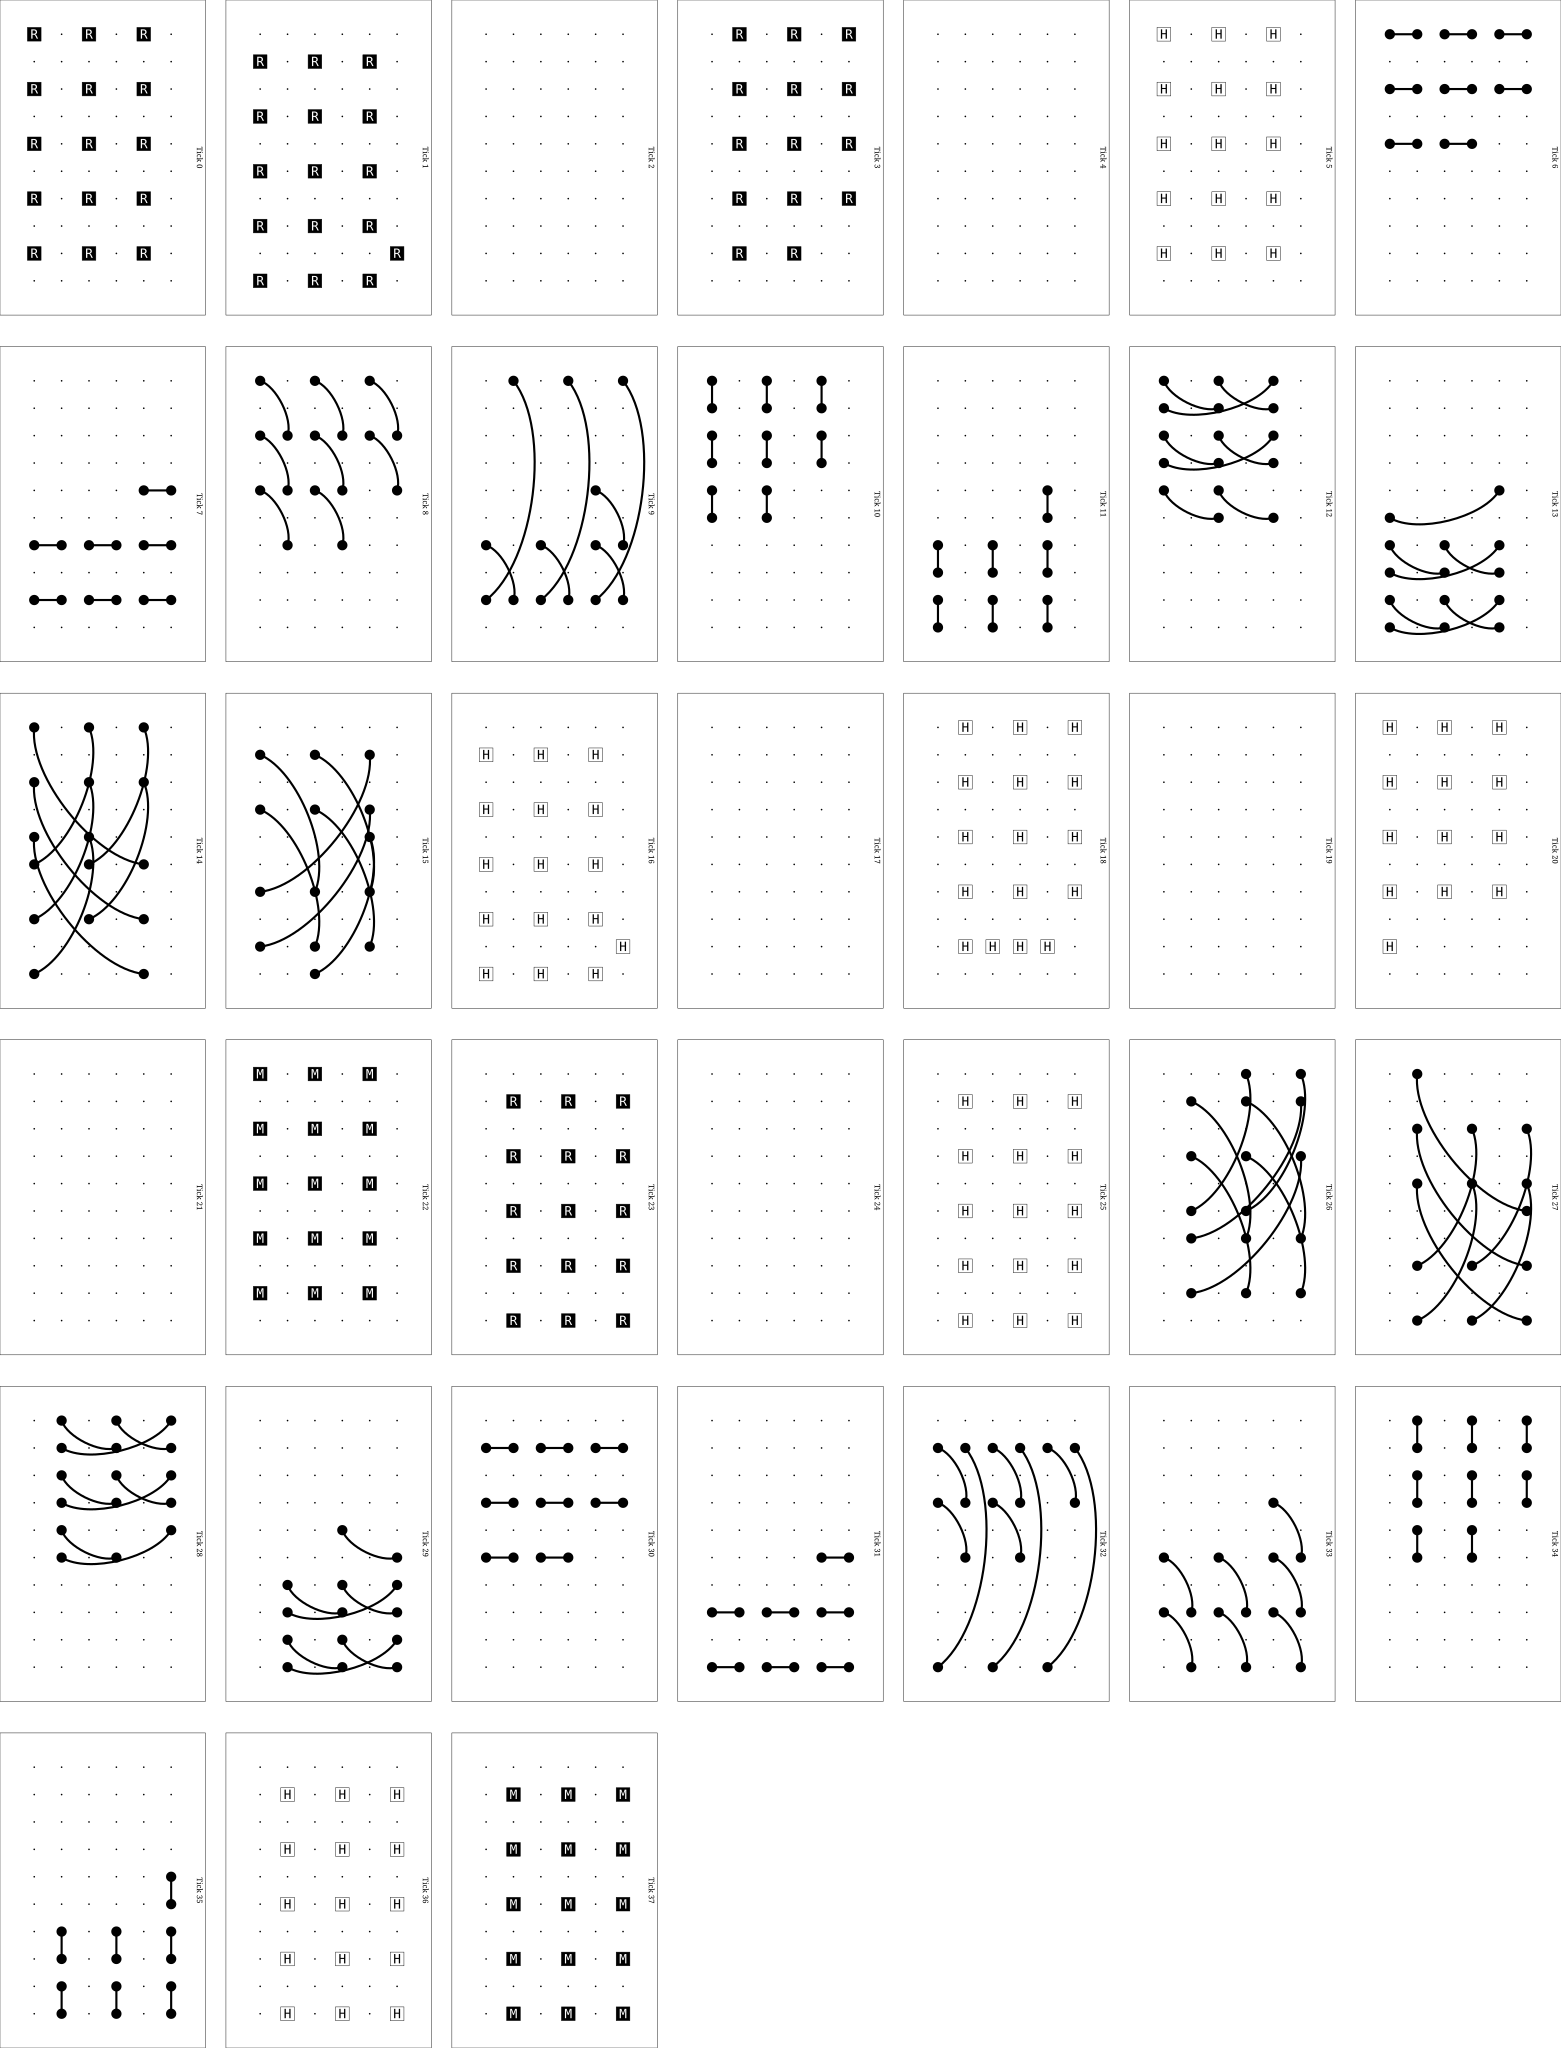

In [30]:
# Visualise its circuit
p = 0.001 # at 0.001 is exactly Helios benchmarks

circuit = make_BB_circuit(  # see src/bb_ions/circfuncs for explanation of make_BB_circuit inputs
    code,
    errors = helios_errors(p, code),
    idle_during = helios_idle_errors(p, code),
    num_syndrome_extraction_cycles = code.d_max,  
    memory_basis = 'X',
    sequential_operations = True, # limited by a certain number of operation zones: 
    num_parallel_1q_ops = 16, # maximum number of single-qubit operations that can be done in one time step
    num_parallel_2q_ops = 8, # 2QRB benchmarks in Helios paper is for four two-qubit gates, four-ion shift, cooling then another four two-qubit gates, so eight two-qubit gates in this "time step" (idling during this time step accounts for it being four then shift, cool, then another four)
    sequential_measurements = True,
    exclude_opposite_basis_detectors = True,
    reuse_check_qubits = False, # As we do X-checks then Z-checks can re-use one set of check qubits. Only reason not to is the diagram looks nicer
    only_CZs = True, # Helios only has RZZ gates
    only_CNOTs = False,
    swapLRC = False,
    loss = True, # Simulated as depolarising noise representing a beacon qubit protocol that replaces lost qubits with ones in the maximally-mixed state

    # LEAKAGE: requires deltakit-stim (see leakage_intro_to_deltakit_stim,ipynb and leakage_with_own_circuit.ipynb) so all set to False in this notebook
    leakage = False, 
    leakage_repumping = False, 
    num_repumping_cycles=0,
    leakage_heralds=False,
)

# display(circuit.without_noise().diagram("timeline-svg"))
display(circuit.without_noise().diagram("timeslice-svg", tick = range(0,38))) # tick range is to just display first round. Delete for whole circuit. 
# order_of_ops(code) # print this line to see the order of terms (a term is x^i*y^j) being applied for the two-qubit gates.

In [31]:
# Generate circuits:

# Clear last example circuits and remake directories:
empty_folder('example_circuits')
empty_folder('example_circuit_diagrams')

ps = [0.001, 0.002] # 0.001 is exactly Helios benchmarks, 0.002 is double etc.
memory_basis = 'X'
num_rounds = code.d_max

for p in ps:
    circuit = make_BB_circuit(  # see src/bb_ions/circfuncs for explanation of make_BB_circuit inputs
        code,
        errors = helios_errors(p, code),
        idle_during = helios_idle_errors(p, code),
        num_syndrome_extraction_cycles = num_rounds,  
        memory_basis = memory_basis,
        sequential_operations = True, # limited by a certain number of operation zones: 
        num_parallel_1q_ops = 16, 
        num_parallel_2q_ops = 8, # 2QRB / 2QCB benchmarks in Helios paper are from repeated application of four two-qubit gates, four-ion shift, cooling then another four two-qubit gates, so eight two-qubit gates in this "time step" and noise applied to qubits undergoing the two-qubit gate, hence we say eight parallel 2q ops for our simulations (but the idling during this time step accounts is actually as if it was shift (280μs), cool (300μs), four two-qubit gates (70μs), then shift, cool, and another four two-qubit gates)
        sequential_measurements = True,
        exclude_opposite_basis_detectors = True,
        reuse_check_qubits = True,
        only_CZs = True, # Helios only has RZZ gates
        swapLRC = False,
        loss = True, # Simulated as depolarising noise representing a beacon qubit protocol that replaces lost qubits with ones in the maximally-mixed state

        # Leakage: requires deltakit-stim (see leakage_intro_to_deltakit_stim,ipynb and leakage_with_own_circuit.ipynb) so all set to False in this notebook
        leakage = False, 
        leakage_repumping = False, 
        num_repumping_cycles=0,
        leakage_heralds=False,
    )


    # Save circuit:
    filename = f"nkd=[[{code.n}_{code.k}_{code.d_max}]],p={p},b={memory_basis},r={num_rounds},l={code.l},m={code.m},A='{''.join(str(x) + str(y) for x, y in code.Aij)}',B='{''.join(str(x) + str(y) for x, y in code.Bij)}'"
    circuit.to_file(f"example_circuits/{filename}.stim")

In [32]:
# # Run memory experiment simulations:

import sinter
import glob
from stimbposd import SinterDecoder_BPOSD, sinter_decoders
import multiprocessing

circuit_paths = glob.glob(f"example_circuits/nkd=[[{code.n}_{code.k}_{code.d_max}*.stim")

csv_path = "example_stats/collected_stats.csv"

tasks = [
    sinter.Task(
        circuit_path = path,
        json_metadata = sinter.comma_separated_key_values(path),
    )
    for path in circuit_paths
]


empty_folder('example_stats') # clear previous example stats

# Collect new stats:
samples = sinter.collect(
    num_workers=multiprocessing.cpu_count(),
    max_shots=10000,
    print_progress = True,
    max_errors=10,
    tasks = tasks,
    decoders=['bposd'],
    save_resume_filepath = csv_path,
    custom_decoders = {
        "bposd": SinterDecoder_BPOSD( # using settings from Ye Delfosse long chain paper [2503.22071] as I have found this to be very fast for only a small hit to performance.
            max_bp_iters = 10_000, 
            bp_method = "min_sum", 
            osd_method = "osd_cs", 
            osd_order = 5 
        )
    },
    )

Starting 8 workers...
2 tasks left:
  workers decoder eta shots_left errors_left json_metadata                                             
        4   bposd   ?      10000          10 nkd=[[30_4_5]],p=0.001,b=X,r=5,l=5,m=3,A='0010',B='000122'
        4   bposd <1m       9999          10 nkd=[[30_4_5]],p=0.002,b=X,r=5,l=5,m=3,A='0010',B='000122'
2 tasks left:
  workers decoder eta shots_left errors_left json_metadata                                             
        4   bposd <1m       8686           9 nkd=[[30_4_5]],p=0.001,b=X,r=5,l=5,m=3,A='0010',B='000122'
        4   bposd <1m       9726          10 nkd=[[30_4_5]],p=0.002,b=X,r=5,l=5,m=3,A='0010',B='000122'
2 tasks left:
  workers decoder eta shots_left errors_left json_metadata                                             
        4   bposd <1m       8396           9 nkd=[[30_4_5]],p=0.001,b=X,r=5,l=5,m=3,A='0010',B='000122'
        4   bposd <1m       9726          10 nkd=[[30_4_5]],p=0.002,b=X,r=5,l=5,m=3,A='0010',B='000122'


Text(0, 0.5, 'pL (logical error in any logical qubit) per round')

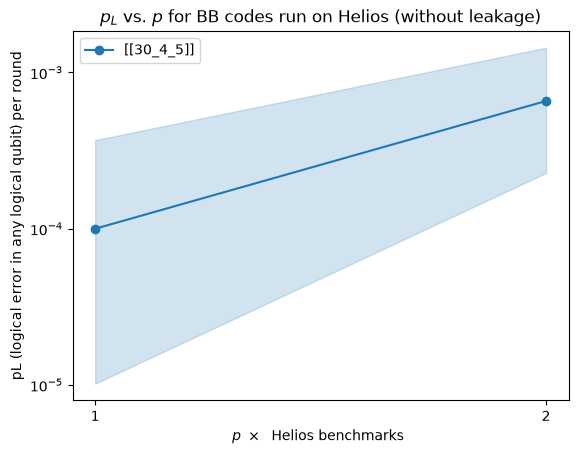

In [33]:
# Plot results:
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, FuncFormatter

# Plot:
collected_stats = sinter.stats_from_csv_files(f'example_stats/collected_stats.csv')

fig, ax = plt.subplots(1, 1)

sinter.plot_error_rate(
    ax=ax,
    stats=collected_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['nkd'],
    failure_units_per_shot_func = lambda stats: stats.json_metadata['r'], # set as num_rounds ('r') failure units to find pL per round
)

ax.loglog()
ax.legend()
ax.set_title("$p_L$ vs. $p$ for BB codes run on Helios (without leakage)")

ax.set_xlabel(r"$p\ \times\ $ Helios benchmarks ") ## Helios noise
ax.xaxis.set_major_locator(LogLocator(10, subs=(1,2,3,4,5,6)))
ax.xaxis.set_major_formatter(FuncFormatter(lambda v,_: ({1:"1",2:"2",3:"3",4:"4",5:"5",6:"6"}.get(int(round(v/10**np.floor(np.log10(v)))), "")) if v>0 else ""))
ax.minorticks_off()

ax.set_ylabel("pL (logical error in any logical qubit) per round")